# Credit Risk Analysis and Modeling - Enhanced Version



In [32]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import gc
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")

# Display helpers
from IPython.display import display, Markdown

# Modeling
from sklearn import preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    learning_curve,
    RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)

import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Data loading

**Idea:** load train and test data from either local paths or relative project paths so the notebook is easier to run on another machine.

In [33]:
# Update these paths if your dataset is stored somewhere else.
TRAIN_CANDIDATES = [
    Path(r"D:/AI_ML/New_repo/fantastic-pancake/data/application_train.csv/application_train.csv"),
    Path("data/application_train.csv"),
    Path("application_train.csv"),
]

TEST_CANDIDATES = [
    Path(r"D:/AI_ML/New_repo/fantastic-pancake/data/application_test.csv/application_test.csv"),
    Path("/content/application_train.csv"),
    Path("application_test.csv"),
]

def resolve_existing_path(candidates):
    for path in candidates:
        if Path(path).exists():
            return Path(path)
    raise FileNotFoundError(
        "Dataset file not found. Please update TRAIN_CANDIDATES / TEST_CANDIDATES with the correct path."
    )

train_path = resolve_existing_path(TRAIN_CANDIDATES)
test_path = resolve_existing_path(TEST_CANDIDATES)

df_train = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

display(Markdown(f"**Train path:** `{train_path}`"))
display(Markdown(f"**Test path:** `{test_path}`"))
print("Train shape:", df_train.shape)
print("Test shape :", test_df.shape)

display(df_train.head())

**Train path:** `application_train.csv`

**Test path:** `/content/application_train.csv`

Train shape: (307511, 122)
Test shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Quick project overview

**Idea:** get a quick feel for size, target balance, and missingness before modeling.

In [34]:
summary_df = pd.DataFrame({
    "rows": [df_train.shape[0], test_df.shape[0]],
    "columns": [df_train.shape[1], test_df.shape[1]],
    "missing_cells": [df_train.isna().sum().sum(), test_df.isna().sum().sum()]
}, index=["train", "test"])

display(summary_df)

target_dist = (
    df_train["TARGET"]
    .value_counts(normalize=True)
    .rename_axis("TARGET")
    .reset_index(name="ratio")
)
target_dist["percent"] = (target_dist["ratio"] * 100).round(2)
display(target_dist)

,rows,columns,missing_cells
train,307511,122,9152465
test,307511,122,9152465


,TARGET,ratio,percent
0,0,0.919271,91.93
1,1,0.080729,8.07


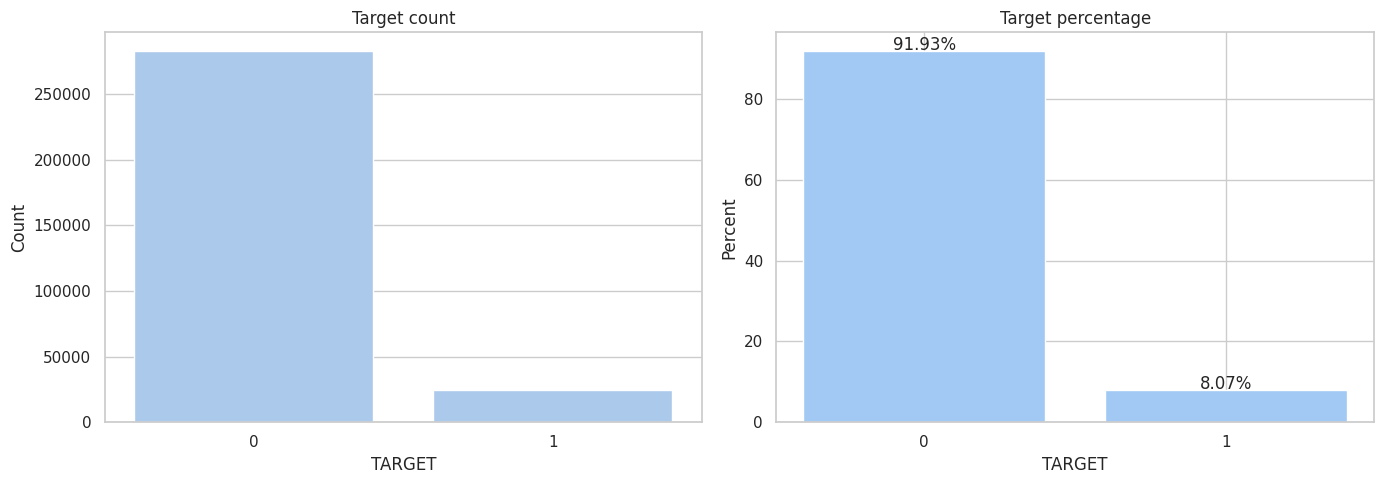

In [35]:
# Output distribution: this makes the class imbalance easy to see.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_train, x="TARGET", ax=axes[0])
axes[0].set_title("Target count")
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Count")

target_plot = df_train["TARGET"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(target_plot.index.astype(str), target_plot.values)
axes[1].set_title("Target percentage")
axes[1].set_xlabel("TARGET")
axes[1].set_ylabel("Percent")
for i, v in enumerate(target_plot.values):
    axes[1].text(i, v + 0.2, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.show()

,feature,missing_percent
0,COMMONAREA_AVG,69.872297
1,COMMONAREA_MODE,69.872297
2,COMMONAREA_MEDI,69.872297
3,NONLIVINGAPARTMENTS_MEDI,69.432963
4,NONLIVINGAPARTMENTS_MODE,69.432963
5,NONLIVINGAPARTMENTS_AVG,69.432963
6,FONDKAPREMONT_MODE,68.386172
7,LIVINGAPARTMENTS_AVG,68.354953
8,LIVINGAPARTMENTS_MEDI,68.354953
9,LIVINGAPARTMENTS_MODE,68.354953


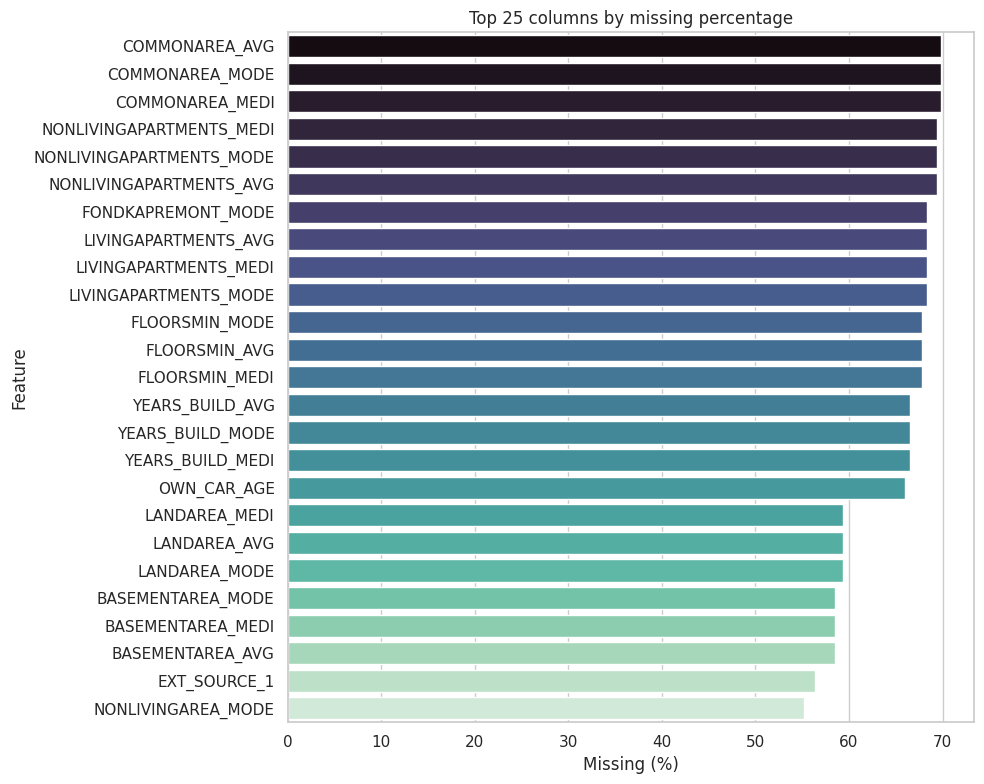

In [36]:
# Show the columns with the highest missing percentage.
missing_pct = (df_train.isna().mean() * 100).sort_values(ascending=False)
missing_top = missing_pct.head(25).reset_index()
missing_top.columns = ["feature", "missing_percent"]

display(missing_top)

plt.figure(figsize=(10, 8))
sns.barplot(data=missing_top, x="missing_percent", y="feature", palette="mako")
plt.title("Top 25 columns by missing percentage")
plt.xlabel("Missing (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 3. Anomaly handling and feature engineering

**Idea:** clean known day-based anomalies and add stronger ratio / aggregation features that are useful in credit-risk data.

In [37]:
# Work on copies so the flow stays clear.
train_fe = df_train.copy()
test_fe = test_df.copy()

# Convert day-based columns to positive day counts for easier reading.
day_cols = [
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"
]
for col in day_cols:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].abs()
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].abs()

# Known anomaly in Home Credit data.
for df in [train_fe, test_fe]:
    df["EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)
    df.loc[df["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

print("EMPLOYED_ANOM counts in train:")
display(train_fe["EMPLOYED_ANOM"].value_counts(dropna=False).to_frame("count"))

EMPLOYED_ANOM counts in train:


,count
EMPLOYED_ANOM,
0,252137
1,55374


In [38]:
# Existing + new engineered features
def add_features(df):
    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in df.columns]
    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]

    # Convert 'Y'/'N' flags to 1/0 for relevant columns before summing
    for col in ["FLAG_OWN_CAR", "FLAG_OWN_REALTY"]:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].map({'Y': 1, 'N': 0}).fillna(0).astype(int)

    bureau_cols = [c for c in df.columns if c.startswith("AMT_REQ_CREDIT_BUREAU_")]
    live_flag_cols = [c for c in df.columns if c.startswith("FLAG_") and "DOCUMENT" not in c]

    # Basic credit burden
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["CREDIT_TERM"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)
    df["GOODS_CREDIT_RATIO"] = df["AMT_GOODS_PRICE"] / (df["AMT_CREDIT"] + 1)
    df["GOODS_INCOME_RATIO"] = df["AMT_GOODS_PRICE"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["PAYMENT_RATE"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)

    # Family / household burden
    if "CNT_FAM_MEMBERS" in df.columns:
        df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1)
        df["CREDIT_PER_PERSON"] = df["AMT_CREDIT"] / (df["CNT_FAM_MEMBERS"] + 1)
    if "CNT_CHILDREN" in df.columns:
        df["INCOME_PER_CHILD"] = df["AMT_INCOME_TOTAL"] / (df["CNT_CHILDREN"] + 1)

    # Time and stability
    df["YEARS_BIRTH"] = df["DAYS_BIRTH"] / 365
    df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"] / 365
    df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1)

    # Log transforms help with skewed financial columns.
    for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
        if col in df.columns:
            df[f"LOG_{col}"] = np.log1p(df[col].clip(lower=0))

    # EXT_SOURCE aggregations
    if len(ext_cols) > 0:
        df["EXT_SOURCE_MEAN"] = df[ext_cols].mean(axis=1)
        df["EXT_SOURCE_STD"] = df[ext_cols].std(axis=1)
        df["EXT_SOURCE_MIN"] = df[ext_cols].min(axis=1)
        df["EXT_SOURCE_MAX"] = df[ext_cols].max(axis=1)
        df["EXT_SOURCE_RANGE"] = df["EXT_SOURCE_MAX"] - df["EXT_SOURCE_MIN"]
        df["EXT_SOURCE_PROD"] = df[ext_cols].prod(axis=1)
        df["EXT_SOURCE_MISSING_COUNT"] = df[ext_cols].isna().sum(axis=1)

    # Aggregate sparse groups into simple signals.
    if len(doc_cols) > 0:
        df["DOC_FLAGS_SUM"] = df[doc_cols].sum(axis=1)
    if len(bureau_cols) > 0:
        df["AMT_REQ_BUREAU_TOTAL"] = df[bureau_cols].sum(axis=1)
    if len(live_flag_cols) > 0:
        df["LIVE_FLAG_SUM"] = df[live_flag_cols].sum(axis=1)

    return df

train_fe = add_features(train_fe)
test_fe = add_features(test_fe)

new_feature_candidates = [
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM",
    "GOODS_CREDIT_RATIO", "GOODS_INCOME_RATIO", "PAYMENT_RATE",
    "INCOME_PER_PERSON", "CREDIT_PER_PERSON", "INCOME_PER_CHILD",
    "YEARS_BIRTH", "YEARS_EMPLOYED", "DAYS_EMPLOYED_RATIO",
    "LOG_AMT_INCOME_TOTAL", "LOG_AMT_CREDIT", "LOG_AMT_ANNUITY", "LOG_AMT_GOODS_PRICE",
    "EXT_SOURCE_MEAN", "EXT_SOURCE_STD", "EXT_SOURCE_MIN", "EXT_SOURCE_MAX",
    "EXT_SOURCE_RANGE", "EXT_SOURCE_PROD", "EXT_SOURCE_MISSING_COUNT",
    "DOC_FLAGS_SUM", "AMT_REQ_BUREAU_TOTAL", "LIVE_FLAG_SUM"
]
created_features = [c for c in new_feature_candidates if c in train_fe.columns]
display(pd.DataFrame({"new_features_added": created_features}))

,new_features_added
0,CREDIT_INCOME_RATIO
1,ANNUITY_INCOME_RATIO
2,CREDIT_TERM
3,GOODS_CREDIT_RATIO
4,GOODS_INCOME_RATIO
5,PAYMENT_RATE
6,INCOME_PER_PERSON
7,CREDIT_PER_PERSON
8,INCOME_PER_CHILD
9,YEARS_BIRTH


## 4. Input vs output visuals

**Idea:** show how important numeric and categorical inputs differ by the output class.

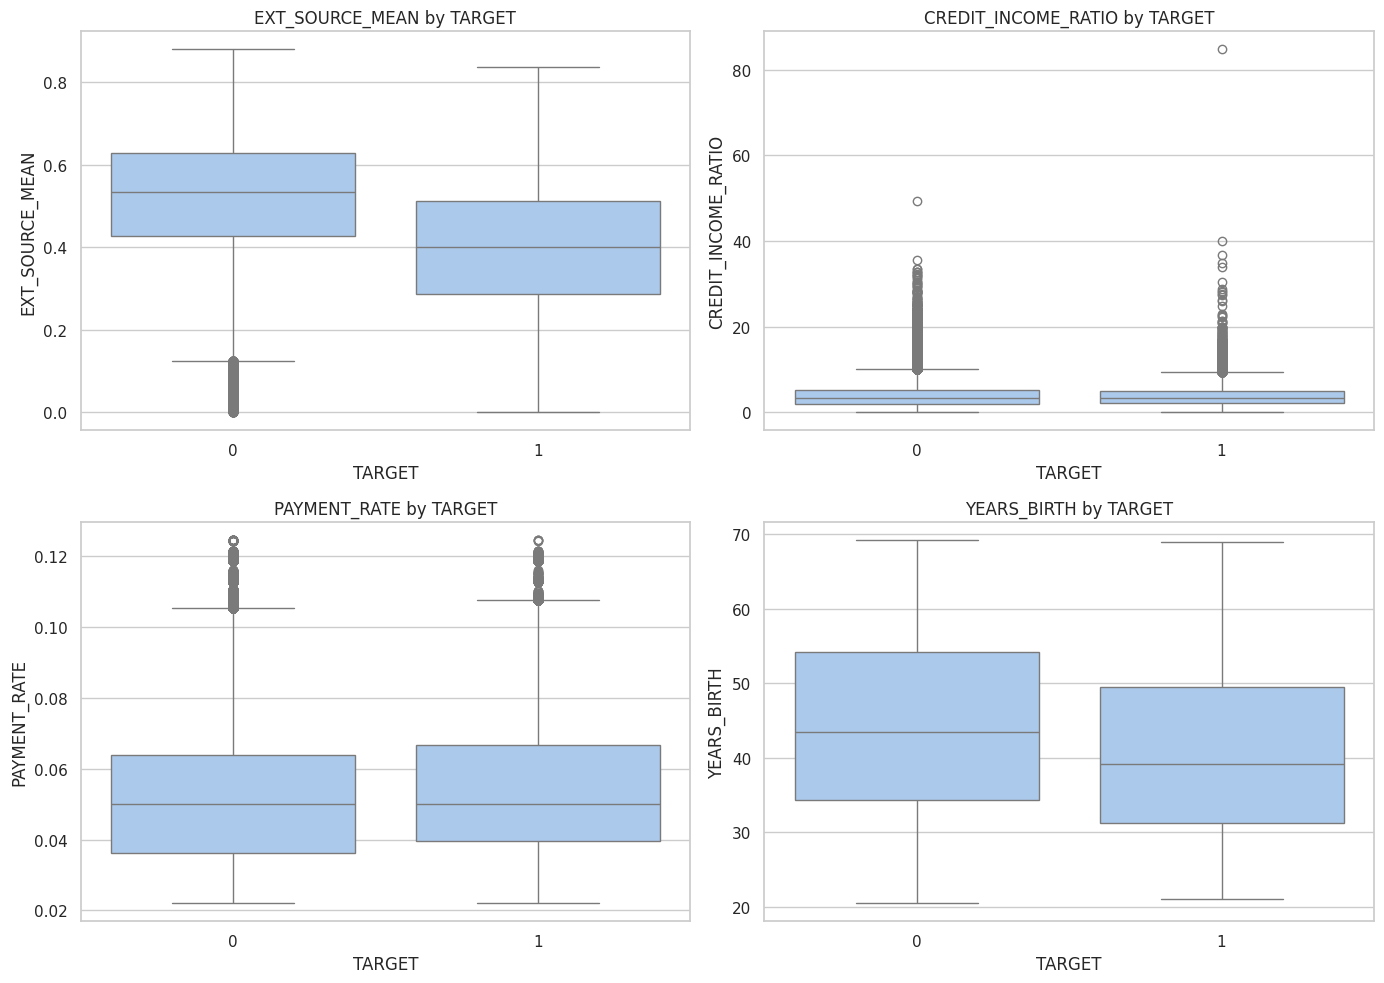

In [39]:
# Short numeric view by target
plot_features = [
    c for c in [
        "EXT_SOURCE_MEAN", "CREDIT_INCOME_RATIO", "PAYMENT_RATE", "YEARS_BIRTH"
    ] if c in train_fe.columns
]

if len(plot_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, col in zip(axes, plot_features):
        sns.boxplot(data=train_fe, x="TARGET", y=col, ax=ax)
        ax.set_title(f"{col} by TARGET")

    # Hide unused axes if any
    for ax in axes[len(plot_features):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

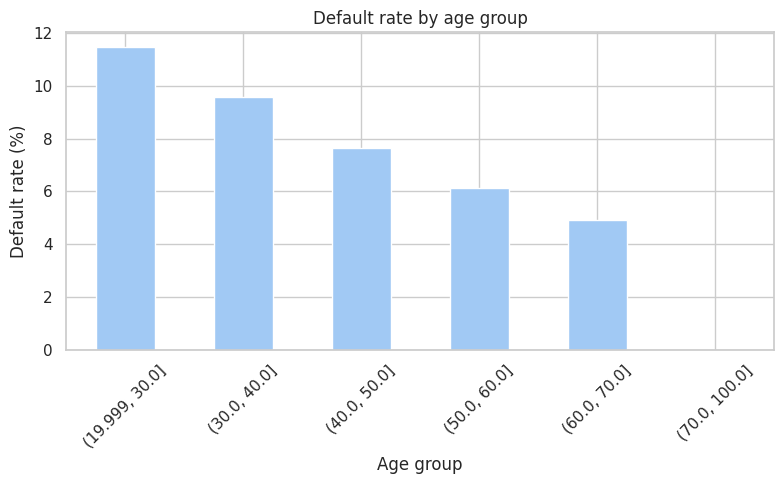

In [40]:
# Age group default rate
if "YEARS_BIRTH" in train_fe.columns:
    age_bins = pd.cut(
        train_fe["YEARS_BIRTH"],
        bins=[20, 30, 40, 50, 60, 70, 100],
        include_lowest=True
    )
    age_default = train_fe.groupby(age_bins)["TARGET"].mean().mul(100)

    plt.figure(figsize=(8, 5))
    age_default.plot(kind="bar")
    plt.title("Default rate by age group")
    plt.xlabel("Age group")
    plt.ylabel("Default rate (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

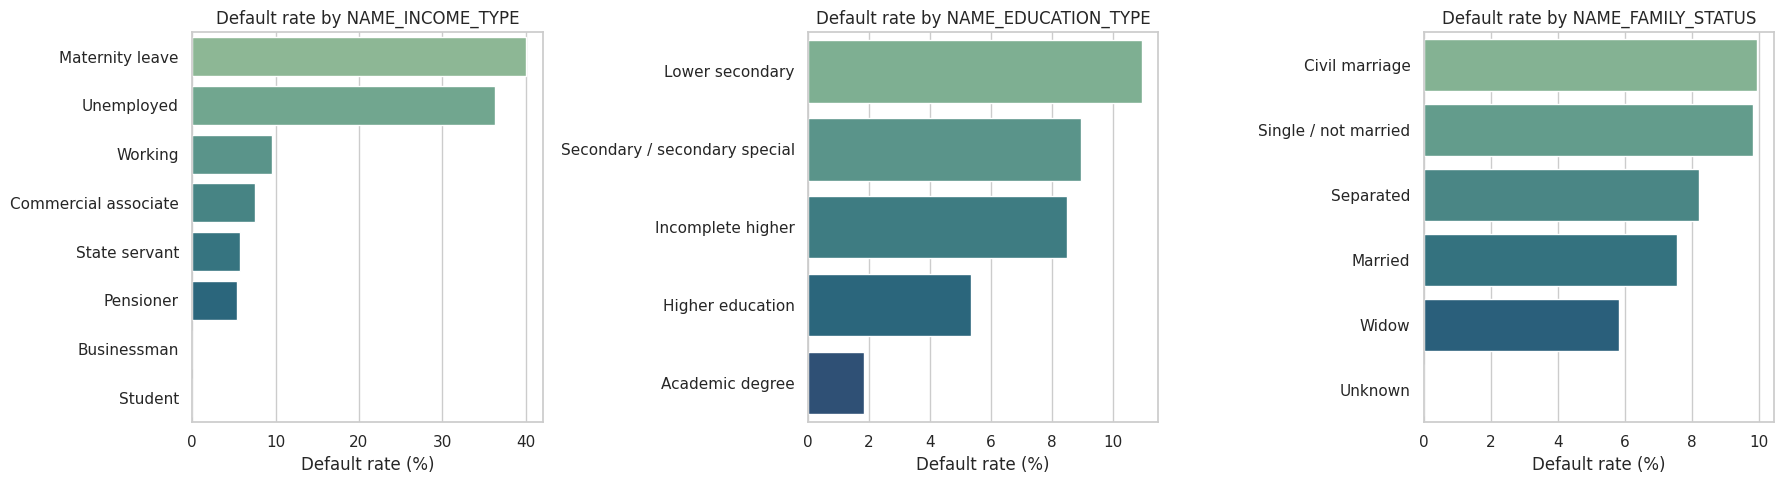

In [41]:
# Categorical default-rate plots
cat_candidates = [c for c in [
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS"
] if c in train_fe.columns]

if len(cat_candidates) > 0:
    fig, axes = plt.subplots(1, len(cat_candidates), figsize=(6 * len(cat_candidates), 5))
    if len(cat_candidates) == 1:
        axes = [axes]

    for ax, col in zip(axes, cat_candidates):
        default_rate = (
            train_fe.groupby(col)["TARGET"]
            .mean()
            .sort_values(ascending=False)
            .head(10)
            .mul(100)
        )
        sns.barplot(x=default_rate.values, y=default_rate.index, ax=ax, palette="crest")
        ax.set_title(f"Default rate by {col}")
        ax.set_xlabel("Default rate (%)")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

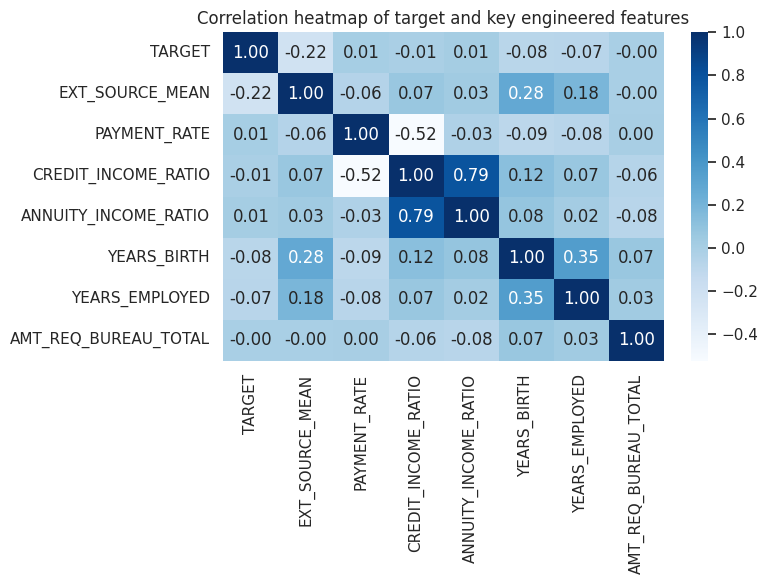

In [42]:
# Correlation heatmap for a few stronger engineered variables.
corr_candidates = [c for c in [
    "TARGET", "EXT_SOURCE_MEAN", "PAYMENT_RATE", "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO", "YEARS_BIRTH", "YEARS_EMPLOYED", "AMT_REQ_BUREAU_TOTAL"
] if c in train_fe.columns]

if len(corr_candidates) >= 3:
    plt.figure(figsize=(8, 6))
    corr = train_fe[corr_candidates].corr()
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation heatmap of target and key engineered features")
    plt.tight_layout()
    plt.show()

## 5. Preprocessing

**Idea:** create missing flags, drop very sparse columns, fill missing values, encode categoricals, and align train/test features.

In [43]:
# Missing flags for columns with at least 1% missing values
missing_ratio_before = train_fe.isna().mean()
cols_to_flag = [
    c for c in missing_ratio_before[missing_ratio_before > 0.01].index
    if c != "TARGET"
]

for col in cols_to_flag:
    train_fe[f"{col}_MISSING"] = train_fe[col].isna().astype(int)
    if col in test_fe.columns:
        test_fe[f"{col}_MISSING"] = test_fe[col].isna().astype(int)

# Drop very high missing columns
high_missing_cols = [
    c for c in train_fe.columns
    if train_fe[c].isna().mean() > 0.60 and c not in ["TARGET", "SK_ID_CURR"]
]
train_fe = train_fe.drop(columns=high_missing_cols)
test_fe = test_fe.drop(columns=[c for c in high_missing_cols if c in test_fe.columns])

# Fill missing values
num_cols = train_fe.select_dtypes(include=np.number).columns.tolist()
cat_cols = train_fe.select_dtypes(include=["object"]).columns.tolist()

for col in num_cols:
    fill_value = train_fe[col].median()
    train_fe[col] = train_fe[col].fillna(fill_value)
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna(fill_value)

for col in cat_cols:
    train_fe[col] = train_fe[col].fillna("missing")
    if col in test_fe.columns:
        test_fe[col] = test_fe[col].fillna("missing")

# Label encode categoricals using train + test together
categorical_features = train_fe.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_features:
    le = preprocessing.LabelEncoder()
    combined = list(train_fe[col].astype(str).values) + list(test_fe[col].astype(str).values)
    le.fit(combined)
    train_fe[col] = le.transform(train_fe[col].astype(str).values)
    test_fe[col] = le.transform(test_fe[col].astype(str).values)

# Force numeric and remove constant columns
train_fe = train_fe.apply(pd.to_numeric, errors="coerce")
test_fe = test_fe.apply(pd.to_numeric, errors="coerce")

constant_cols = [c for c in train_fe.columns if train_fe[c].nunique(dropna=False) <= 1]
train_fe = train_fe.drop(columns=constant_cols)
test_fe = test_fe.drop(columns=[c for c in constant_cols if c in test_fe.columns])

# Build modeling matrices
drop_cols = ["TARGET", "SK_ID_CURR"]
X = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
y = train_fe["TARGET"].copy()
X_test = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns], errors="ignore")
X_test = X_test.reindex(columns=X.columns, fill_value=-999)

prep_summary = pd.DataFrame({
    "metric": [
        "missing_flag_columns",
        "high_missing_columns_dropped",
        "constant_columns_dropped",
        "final_feature_count",
        "train_rows",
        "test_rows"
    ],
    "value": [
        len(cols_to_flag),
        len(high_missing_cols),
        len(constant_cols),
        X.shape[1],
        X.shape[0],
        X_test.shape[0]
    ]
})
display(prep_summary)

,metric,value
0,missing_flag_columns,61
1,high_missing_columns_dropped,17
2,constant_columns_dropped,0
3,final_feature_count,191
4,train_rows,307511
5,test_rows,307511


## 6. Feature selection

**Idea:** use Random Forest importance to keep the strongest 95% cumulative importance features and reduce noise.

,feature,importance,cumulative_importance
0,EXT_SOURCE_MEAN,0.234473,0.234473
1,EXT_SOURCE_MIN,0.110233,0.344705
2,EXT_SOURCE_MAX,0.060484,0.405190
3,EXT_SOURCE_PROD,0.059353,0.464543
4,GOODS_CREDIT_RATIO,0.045806,0.510349
5,EXT_SOURCE_3,0.029492,0.539840
6,DAYS_EMPLOYED_RATIO,0.018365,0.558206
7,EXT_SOURCE_2,0.017325,0.575531
8,EXT_SOURCE_STD,0.016640,0.592170
9,PAYMENT_RATE,0.016140,0.608311


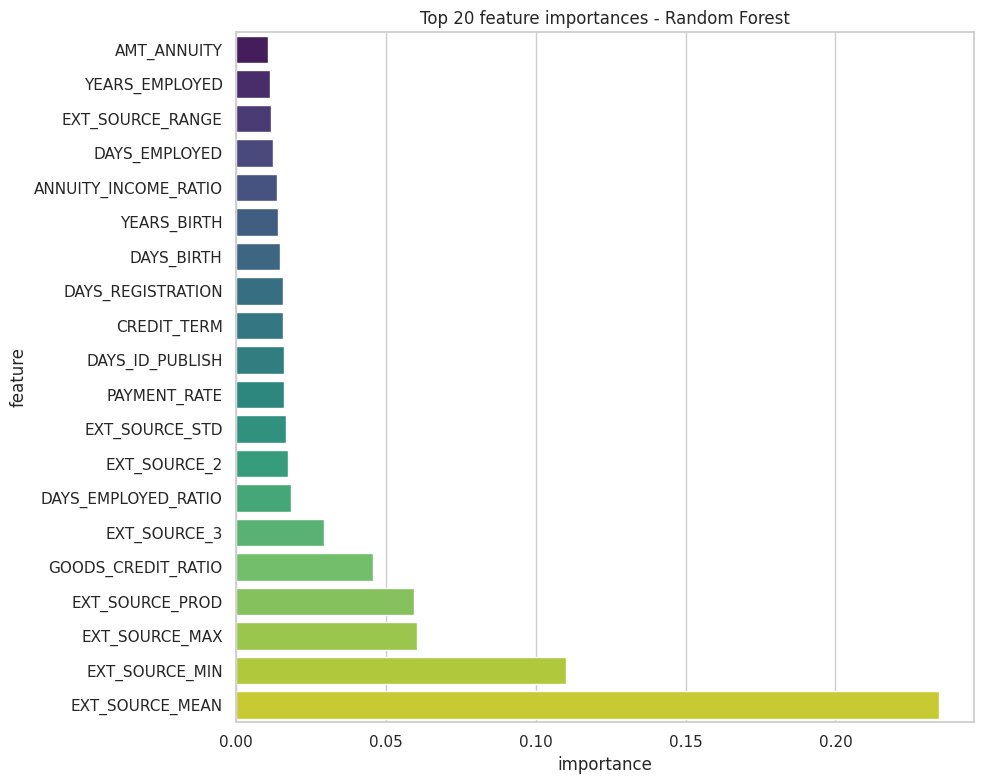

Selected feature count: 65


In [44]:
rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_leaf=4,
    max_features=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X, y)

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": rf.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
feature_importance["cumulative_importance"] = feature_importance["importance"].cumsum()

display(feature_importance.head(20))

selected_features = feature_importance.loc[
    feature_importance["cumulative_importance"] <= 0.95, "feature"
].tolist()

if len(selected_features) < 25:
    # Keep a healthy minimum so the selected set does not become too small.
    selected_features = feature_importance.head(40)["feature"].tolist()

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20).sort_values("importance"),
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 20 feature importances - Random Forest")
plt.tight_layout()
plt.show()

print("Selected feature count:", len(selected_features))

In [45]:
X_selected = X[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Logistic Regression needs scaling. Tree models do not.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)

Train size: (246008, 65)
Validation size: (61503, 65)


## 7. Model training and evaluation

**Idea:** compare multiple models in one place and collect ROC-AUC, PR-AUC, threshold metrics, confusion matrices, and learning curves.

In [46]:
models = {
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,
        random_state=RANDOM_STATE
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=float((y_train == 0).sum() / max((y_train == 1).sum(), 1)),
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

def find_best_threshold(y_true, y_prob):
    rows = []
    for t in np.arange(0.10, 0.91, 0.05):
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": round(float(t), 2),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
    return threshold_df, float(best_row["threshold"])

def evaluate_model(name, model):
    # Fit using scaled data only for Logistic Regression
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_val)[:, 1]

    # Default predictions and best-threshold predictions
    y_pred_default = (y_prob >= 0.50).astype(int)
    threshold_df, best_threshold = find_best_threshold(y_val, y_prob)
    y_pred_best = (y_prob >= best_threshold).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_val, y_prob),
        "pr_auc": average_precision_score(y_val, y_prob),
        "best_threshold": best_threshold,
        "f1_default": f1_score(y_val, y_pred_default, zero_division=0),
        "f1_best": f1_score(y_val, y_pred_best, zero_division=0),
        "precision_best": precision_score(y_val, y_pred_best, zero_division=0),
        "recall_best": recall_score(y_val, y_pred_best, zero_division=0),
    }

    fpr, tpr, _ = roc_curve(y_val, y_prob)
    precision, recall, _ = precision_recall_curve(y_val, y_prob)

    return {
        "name": name,
        "model": model,
        "y_prob": y_prob,
        "y_pred_default": y_pred_default,
        "y_pred_best": y_pred_best,
        "metrics": metrics,
        "threshold_df": threshold_df,
        "roc_curve": (fpr, tpr),
        "pr_curve": (precision, recall)
    }

eval_outputs = {}
for name, model in models.items():
    eval_outputs[name] = evaluate_model(name, model)

results_df = pd.DataFrame([v["metrics"] for v in eval_outputs.values()]).sort_values(
    "roc_auc", ascending=False
).reset_index(drop=True)

display(results_df)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.239344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12420
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


,model,roc_auc,pr_auc,best_threshold,f1_default,f1_best,precision_best,recall_best
0,LightGBM,0.766042,0.257557,0.65,0.280634,0.318466,0.249063,0.441490
1,XGBoost,0.763408,0.257916,0.65,0.284905,0.317733,0.256366,0.417724
2,Logistic Regression,0.748127,0.235493,0.65,0.260994,0.297219,0.226367,0.432628


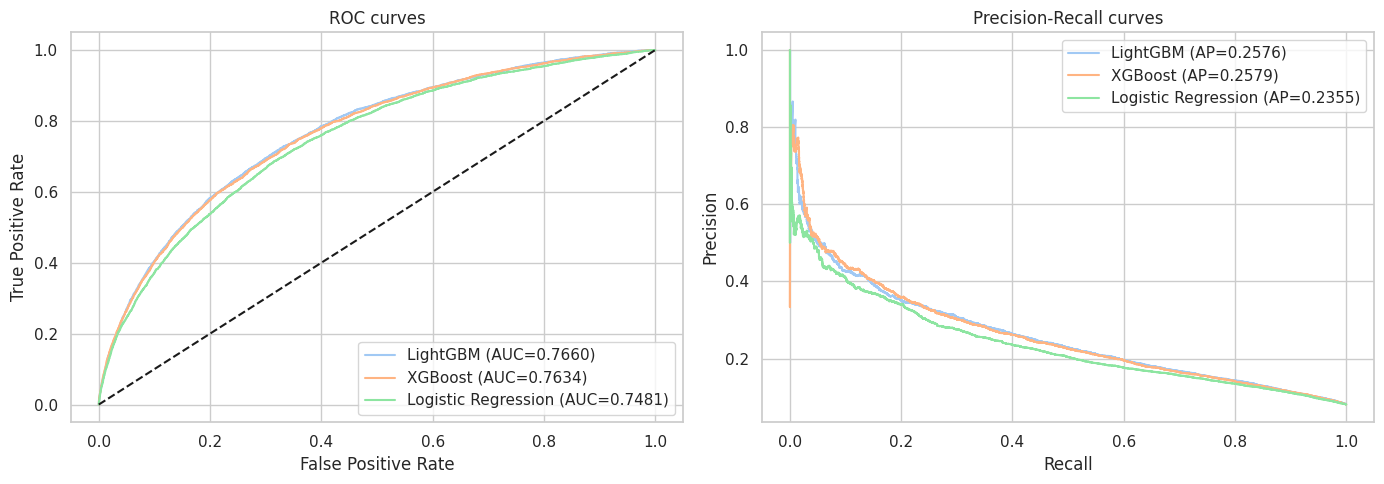

In [47]:
# Combined ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in eval_outputs.items():
    fpr, tpr = res["roc_curve"]
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['metrics']['roc_auc']:.4f})")

    precision, recall = res["pr_curve"]
    axes[1].plot(recall, precision, label=f"{name} (AP={res['metrics']['pr_auc']:.4f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].set_title("Precision-Recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

In [48]:
# Classification reports shown clearly model by model
for name, res in eval_outputs.items():
    display(Markdown(f"### {name}"))
    print("Default threshold = 0.50")
    print(classification_report(y_val, res["y_pred_default"], zero_division=0))
    print(f"Best threshold = {res['metrics']['best_threshold']:.2f}")
    print(classification_report(y_val, res["y_pred_best"], zero_division=0))

### LightGBM

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503

Best threshold = 0.65
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.25      0.44      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.62     61503
weighted avg       0.89      0.85      0.87     61503



### XGBoost

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.18      0.63      0.28      4965

    accuracy                           0.75     61503
   macro avg       0.57      0.69      0.57     61503
weighted avg       0.90      0.75      0.80     61503

Best threshold = 0.65
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.26      0.42      0.32      4965

    accuracy                           0.86     61503
   macro avg       0.60      0.66      0.62     61503
weighted avg       0.89      0.86      0.87     61503



### Logistic Regression

Default threshold = 0.50
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

Best threshold = 0.65
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     56538
           1       0.23      0.43      0.30      4965

    accuracy                           0.83     61503
   macro avg       0.59      0.65      0.60     61503
weighted avg       0.89      0.83      0.86     61503



## 8. Confusion matrices

**Idea:** show confusion matrices at the default threshold and also at the best F1 threshold for each model.

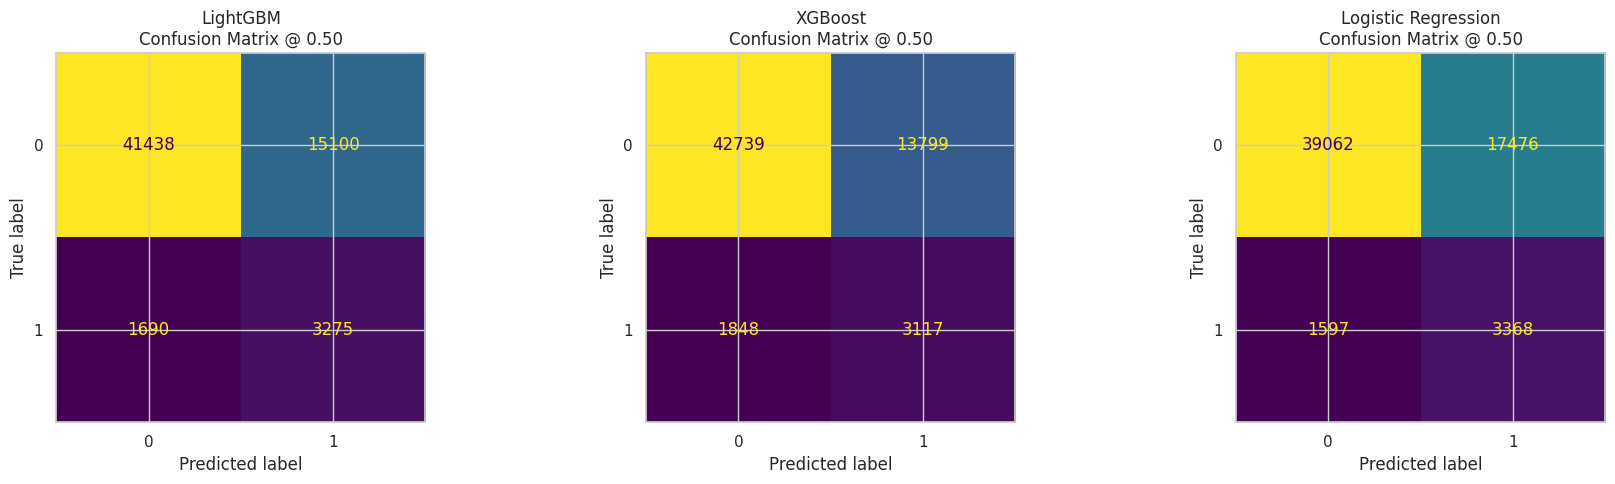

In [49]:
# Default-threshold confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, eval_outputs.items()):
    cm = confusion_matrix(y_val, res["y_pred_default"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nConfusion Matrix @ 0.50")
plt.tight_layout()
plt.show()

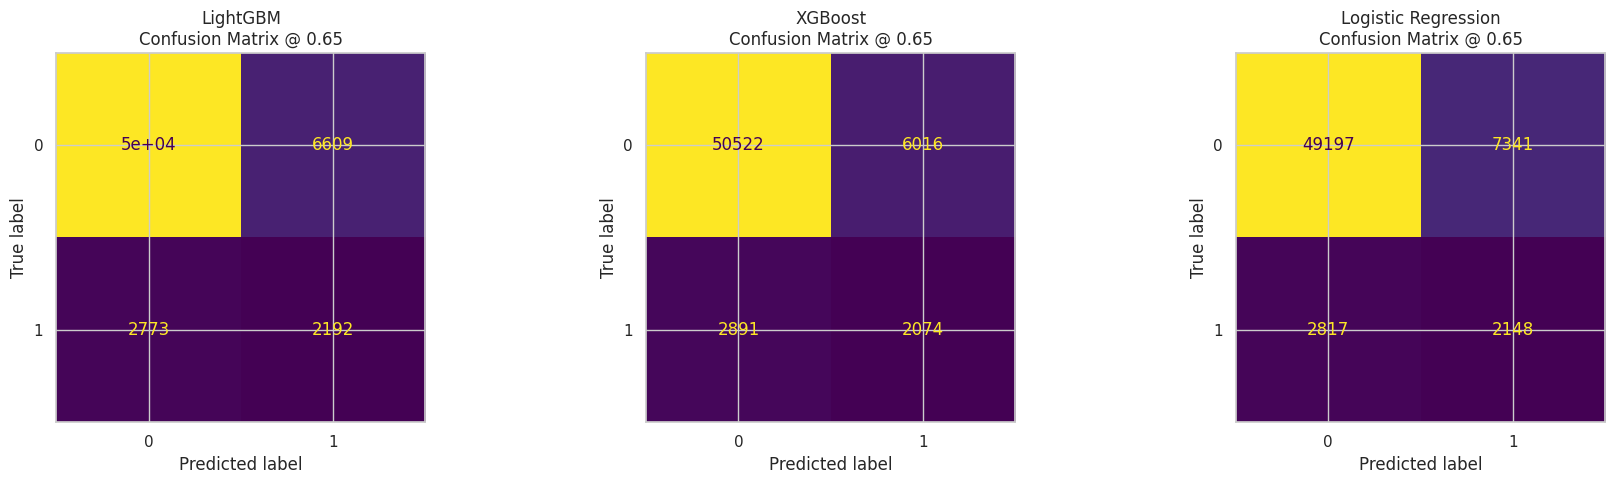

In [50]:
# Best-threshold confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, eval_outputs.items()):
    cm = confusion_matrix(y_val, res["y_pred_best"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nConfusion Matrix @ {res['metrics']['best_threshold']:.2f}")
plt.tight_layout()
plt.show()

## 9. Threshold behavior

**Idea:** this section shows how precision, recall, and F1 change across thresholds so the final cutoff is easier to justify.

**Best validation ROC-AUC model:** LightGBM

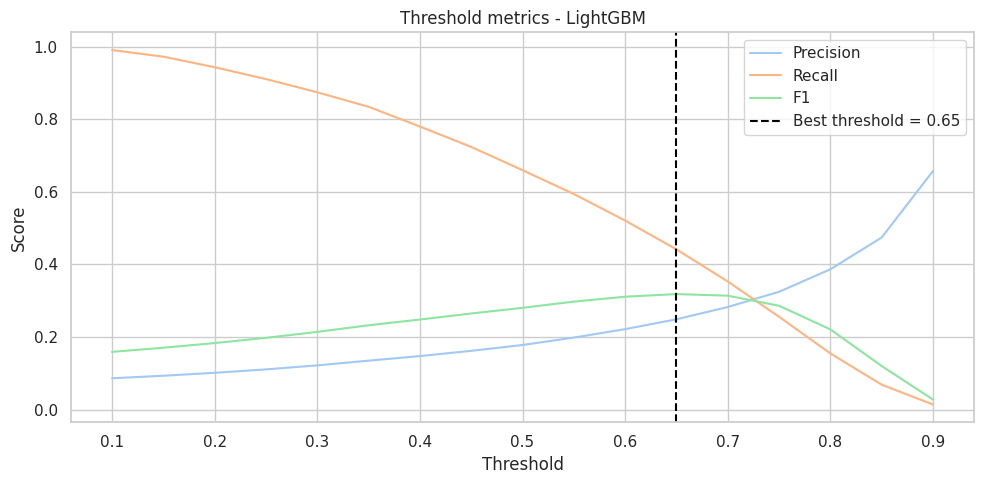

,threshold,precision,recall,f1
0,0.10,0.086626,0.990534,0.159318
1,0.15,0.093586,0.972205,0.170737
2,0.20,0.101670,0.943202,0.183553
3,0.25,0.111046,0.910574,0.197951
4,0.30,0.122154,0.874119,0.214353
5,0.35,0.135117,0.834240,0.232566
6,0.40,0.147702,0.779859,0.248364
7,0.45,0.162212,0.723666,0.265019
8,0.50,0.178231,0.659617,0.280634
9,0.55,0.198626,0.593958,0.297698


In [51]:
best_model_name = results_df.iloc[0]["model"]
best_res = eval_outputs[best_model_name]

display(Markdown(f"**Best validation ROC-AUC model:** {best_model_name}"))

plt.figure(figsize=(10, 5))
threshold_df = best_res["threshold_df"]
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_res["metrics"]["best_threshold"], linestyle="--", color="black",
            label=f"Best threshold = {best_res['metrics']['best_threshold']:.2f}")
plt.title(f"Threshold metrics - {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

display(threshold_df)

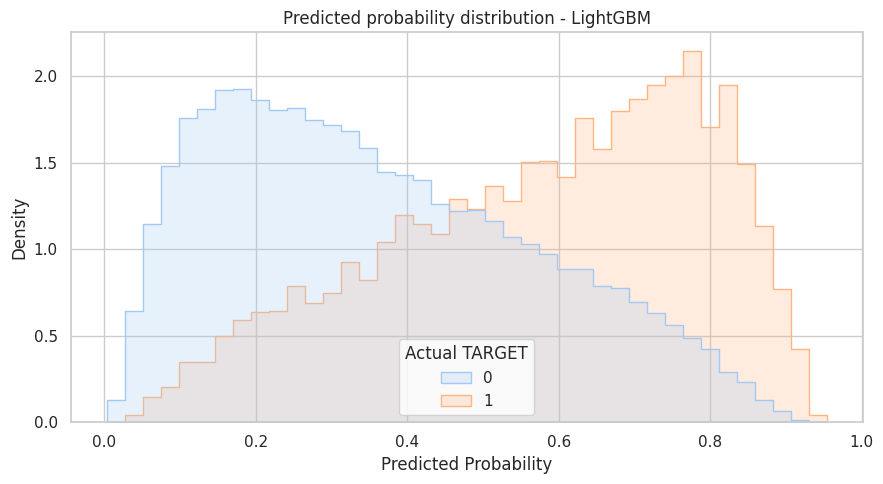

In [52]:
# Probability separation plot for the best model
prob_df = pd.DataFrame({
    "Actual TARGET": y_val.values,
    "Predicted Probability": best_res["y_prob"]
})

plt.figure(figsize=(9, 5))
sns.histplot(
    data=prob_df,
    x="Predicted Probability",
    hue="Actual TARGET",
    bins=40,
    element="step",
    stat="density",
    common_norm=False
)
plt.title(f"Predicted probability distribution - {best_model_name}")
plt.tight_layout()
plt.show()

## 10. Learning curves

**Idea:** learning curves show whether the model is improving with more data or starting to level off.

**Note:** to keep runtime practical, the plot uses a sampled training subset when the dataset is very large.

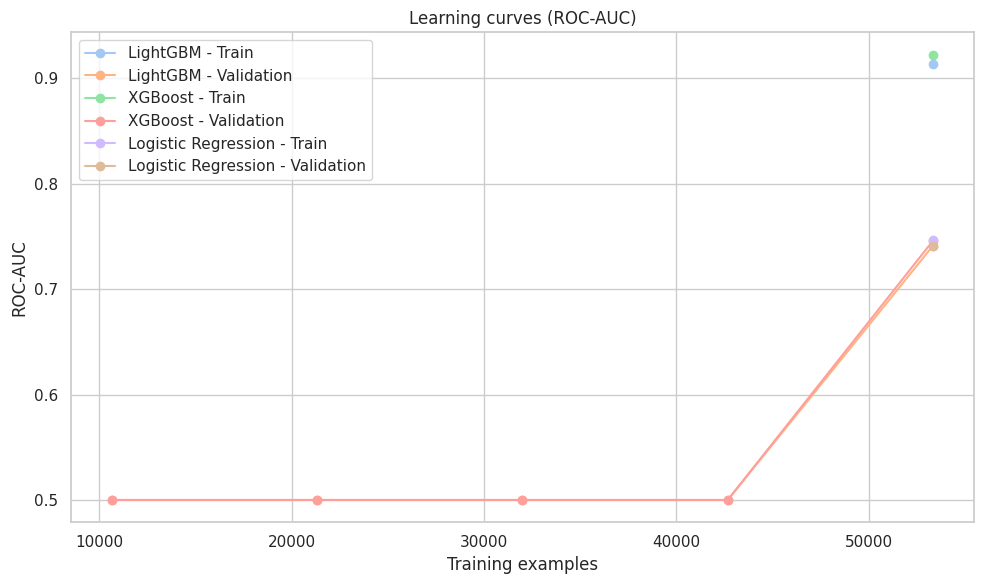

In [53]:
def plot_learning_curve_for_model(name, model, X_data, y_data, scaled=False, max_samples=80000):
    # Sample rows for plotting only, so this section stays practical on large data.
    if len(X_data) > max_samples:
        sample_idx = pd.Series(y_data).groupby(y_data).sample(
            frac=max_samples / len(X_data),
            random_state=RANDOM_STATE
        ).index
        X_plot = X_data.loc[sample_idx]
        y_plot = y_data.loc[sample_idx]
    else:
        X_plot = X_data.copy()
        y_plot = y_data.copy()

    if scaled:
        X_used = StandardScaler().fit_transform(X_plot)
    else:
        X_used = X_plot

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_used,
        y_plot,
        cv=3,
        scoring="roc_auc",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, marker="o", label=f"{name} - Train")
    plt.plot(train_sizes, val_mean, marker="o", label=f"{name} - Validation")

plt.figure(figsize=(10, 6))
plot_learning_curve_for_model(
    "LightGBM",
    lgb.LGBMClassifier(n_estimators=250, learning_rate=0.05, is_unbalance=True, random_state=RANDOM_STATE),
    X_selected, y, scaled=False
)
plot_learning_curve_for_model(
    "XGBoost",
    xgb.XGBClassifier(n_estimators=250, learning_rate=0.05, max_depth=6, eval_metric="logloss", random_state=RANDOM_STATE),
    X_selected, y, scaled=False
)
plot_learning_curve_for_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    X_selected, y, scaled=True
)

plt.title("Learning curves (ROC-AUC)")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Cross-validation check for the strongest tree model

**Idea:** one train/validation split is useful, but CV gives a more stable view of performance.

In [54]:
cv_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,
    random_state=RANDOM_STATE
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_scores = []
oof_preds = np.zeros(len(X_selected))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_selected, y), start=1):
    X_tr, X_va = X_selected.iloc[tr_idx], X_selected.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    cv_model.fit(X_tr, y_tr)
    y_va_prob = cv_model.predict_proba(X_va)[:, 1]
    oof_preds[va_idx] = y_va_prob
    fold_auc = roc_auc_score(y_va, y_va_prob)
    fold_scores.append(fold_auc)
    print(f"Fold {fold}: AUC = {fold_auc:.5f}")

cv_auc = roc_auc_score(y, oof_preds)
cv_summary = pd.DataFrame({
    "fold": list(range(1, 6)),
    "auc": fold_scores
})
display(cv_summary)
print("OOF AUC:", round(cv_auc, 5))
print("Mean CV :", round(np.mean(fold_scores), 5))
print("Std CV  :", round(np.std(fold_scores), 5))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.071383 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12332
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Fold 1: AUC = 0.75935
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12429
[LightGBM] [Info] Number of data points in the train set: 246009, number of used fea

,fold,auc
0,1,0.759354
1,2,0.765557
2,3,0.758358
3,4,0.767034
4,5,0.759247


OOF AUC: 0.76189
Mean CV : 0.76191
Std CV  : 0.00363


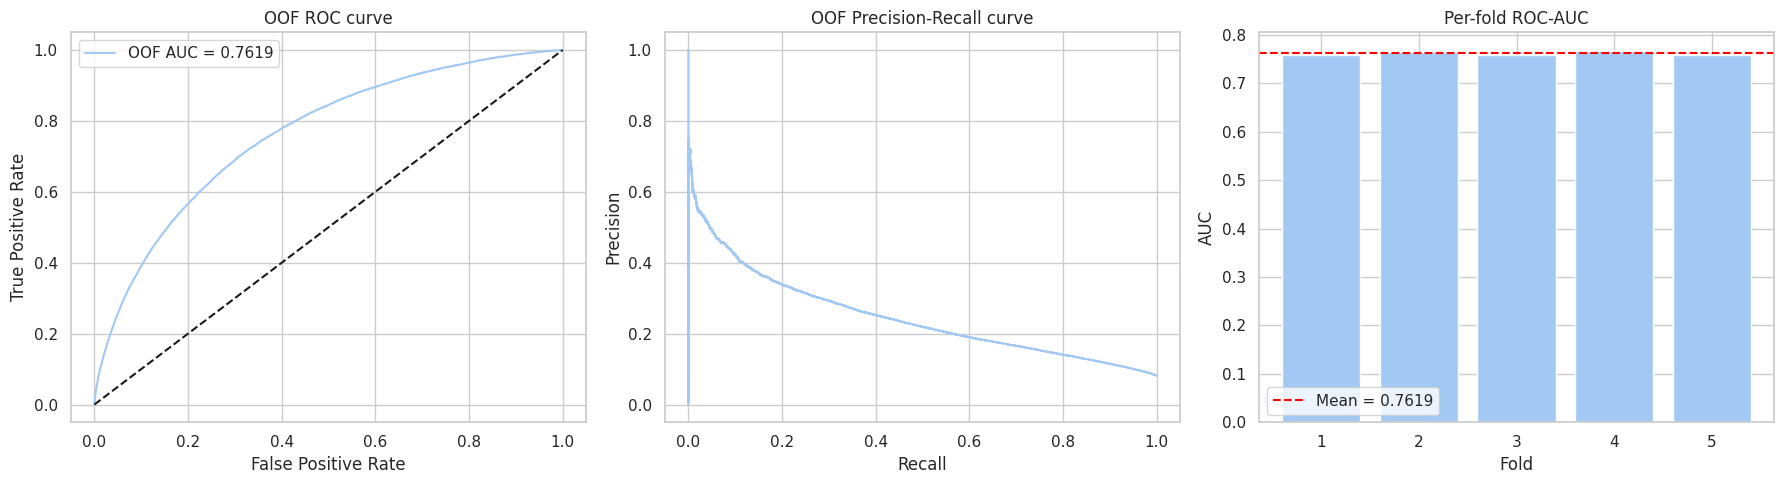

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curve from OOF predictions
fpr, tpr, _ = roc_curve(y, oof_preds)
axes[0].plot(fpr, tpr, label=f"OOF AUC = {cv_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("OOF ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR curve from OOF predictions
precision, recall, _ = precision_recall_curve(y, oof_preds)
axes[1].plot(recall, precision)
axes[1].set_title("OOF Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

# Fold score bar chart
axes[2].bar(cv_summary["fold"], cv_summary["auc"])
axes[2].axhline(cv_summary["auc"].mean(), linestyle="--", color="red",
                label=f"Mean = {cv_summary['auc'].mean():.4f}")
axes[2].set_title("Per-fold ROC-AUC")
axes[2].set_xlabel("Fold")
axes[2].set_ylabel("AUC")
axes[2].legend()

plt.tight_layout()
plt.show()

## 12. Feature importance from the best tree model

**Idea:** show which variables are pushing the final tree-based model the most.

[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12432
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486


,feature,importance
9,PAYMENT_RATE,1224
13,DAYS_BIRTH,671
10,DAYS_ID_PUBLISH,554
4,GOODS_CREDIT_RATIO,526
20,DAYS_LAST_PHONE_CHANGE,513
12,DAYS_REGISTRATION,508
0,EXT_SOURCE_MEAN,481
5,EXT_SOURCE_3,467
7,EXT_SOURCE_2,420
19,AMT_ANNUITY,413


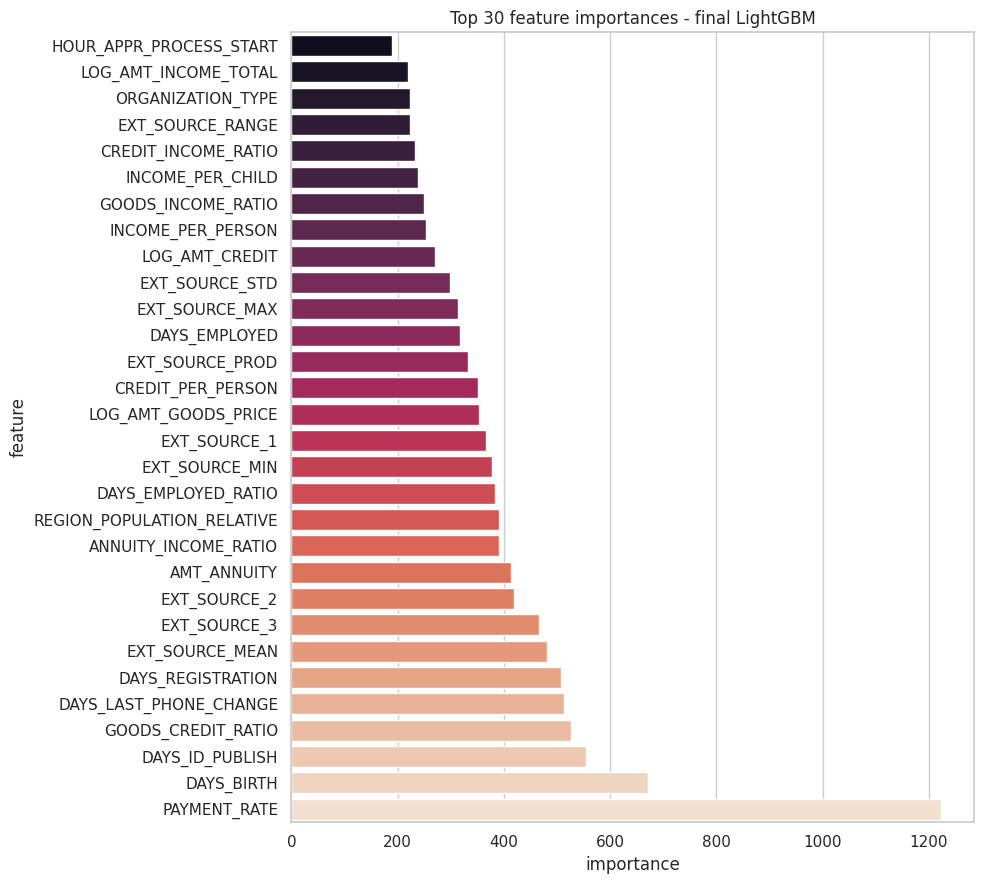

In [56]:
# Fit the best tree model on all selected data to show final importance.
final_tree_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,
    random_state=RANDOM_STATE
)
final_tree_model.fit(X_selected, y)

final_importance = (
    pd.DataFrame({
        "feature": X_selected.columns,
        "importance": final_tree_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(30)
)

display(final_importance.head(15))

plt.figure(figsize=(10, 9))
sns.barplot(
    data=final_importance.sort_values("importance"),
    x="importance",
    y="feature",
    palette="rocket"
)
plt.title("Top 30 feature importances - final LightGBM")
plt.tight_layout()
plt.show()

## 13. Final notes

**Short reading guide:**
- use the result table for model comparison
- use confusion matrices to inspect false positives and false negatives
- use the threshold plot to choose a cutoff
- use learning curves to see whether more data might still help
- use feature importance to explain the model